# 05 Stream B: Feature Group Ablation

## Purpose

This notebook is the code for Stream B of the project: interpretation through feature group ablation.

Unlike Stream A, which focuses on optimization through feature selection, Stream B focuses on explaining which types of features contribute most to multiclass intrusion detection performance.

The pipeline decisions from Ablation 1 and Ablation 2 are fixed:

- Class imbalance strategy: loaded from `ablation1_best_config.json`
- Encoding strategy: loaded from `ablation2_best_config.json`
- Model: Random Forest
- Train/test split: same baseline split from Notebook 02

## Main question

Which feature group causes the largest decrease in attack-class recall when removed?

## Interpretation rule

For each feature group:

\[
Impact = Baseline\ score - Score\ after\ removing\ that\ group
\]

A larger positive drop means the removed feature group was more important.

## Primary metric

Average attack-class Recall, excluding the Normal class.

## Secondary metrics

- Macro F1
- Per-class recall
- Number of attacks predicted as Normal

In [1]:
import pandas as pd
import numpy as np
import json
import warnings

from pathlib import Path

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
FIGURE_DIR = PROJECT_ROOT / "reports"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

matplotlib.rcParams["font.family"] = "DejaVu Sans"

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data directory:", PROCESSED_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("Figure directory:", FIGURE_DIR.resolve())

Project root: C:\Projects\nid-data-mining
Processed data directory: C:\Projects\nid-data-mining\data\processed
Output directory: C:\Projects\nid-data-mining\data\outputs
Figure directory: C:\Projects\nid-data-mining\reports


In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_baseline.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_baseline.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_baseline.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test_baseline.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train: (2032037, 43)
X_test: (508010, 43)
y_train: (2032037,)
y_test: (508010,)

Train class distribution:
attack_cat
Normal            1775011
Generic            172385
Exploits            35620
Fuzzers             19397
DoS                 13082
Reconnaissance      11189
Analysis             2142
Backdoor             1863
Shellcode            1209
Worms                 139
Name: count, dtype: int64

Test class distribution:
attack_cat
Normal            443753
Generic            43096
Exploits            8905
Fuzzers             4849
DoS                 3271
Reconnaissance      2798
Analysis             535
Backdoor             466
Shellcode            302
Worms                 35
Name: count, dtype: int64


In [3]:
ablation1_config_path = OUTPUT_DIR / "ablation1_best_config.json"
ablation2_config_path = OUTPUT_DIR / "ablation2_best_config.json"

if ablation1_config_path.exists():
    with open(ablation1_config_path, "r") as f:
        ablation1_config = json.load(f)
    BEST_IMBALANCE_STRATEGY = ablation1_config["best_strategy"]
    OVERSAMPLE_CAP_VALUE = int(ablation1_config.get("oversample_cap_value", 50_000))
else:
    BEST_IMBALANCE_STRATEGY = "Capped_SMOTENC_50k"
    OVERSAMPLE_CAP_VALUE = 50_000

if ablation2_config_path.exists():
    with open(ablation2_config_path, "r") as f:
        ablation2_config = json.load(f)
    BEST_ENCODING = ablation2_config["best_encoding"]
else:
    BEST_ENCODING = "Ordinal Encoding"

print("Best Ablation 1 imbalance strategy:", BEST_IMBALANCE_STRATEGY)
print("Oversample cap value:", OVERSAMPLE_CAP_VALUE)
print("Best Ablation 2 encoding strategy:", BEST_ENCODING)

Best Ablation 1 imbalance strategy: Capped_SMOTENC_50k
Oversample cap value: 50000
Best Ablation 2 encoding strategy: Ordinal Encoding


## Fixed pipeline for Stream B

Stream B uses the best preprocessing choices from Ablation 1 and Ablation 2.

Only the feature group changes across experiments.

This means the experiment is controlled:

- Same train/test split
- Same Random Forest model
- Same class imbalance strategy
- Same encoding strategy
- Different removed feature group

In [4]:
NOMINAL_CATEGORICAL_COLS = ["proto", "state", "service"]
NUMERIC_LIKE_COLS = ["sport", "dsport", "ct_ftp_cmd"]

print("Nominal categorical columns:", NOMINAL_CATEGORICAL_COLS)
print("Numeric-like columns:", NUMERIC_LIKE_COLS)

def clean_numeric_like_columns(X_train_input, X_test_input, numeric_like_cols):
    X_train_clean = X_train_input.copy()
    X_test_clean = X_test_input.copy()

    for col in numeric_like_cols:
        if col not in X_train_clean.columns:
            continue

        X_train_clean[col] = pd.to_numeric(X_train_clean[col], errors="coerce")
        X_test_clean[col] = pd.to_numeric(X_test_clean[col], errors="coerce")

        fill_value = X_train_clean[col].mean()

        if pd.isna(fill_value):
            fill_value = 0

        X_train_clean[col] = X_train_clean[col].fillna(fill_value).astype(np.float32)
        X_test_clean[col] = X_test_clean[col].fillna(fill_value).astype(np.float32)

    return X_train_clean, X_test_clean


def prepare_ordinal_features(X_train_input, X_test_input, categorical_cols, numeric_like_cols):
    X_train_enc, X_test_enc = clean_numeric_like_columns(
        X_train_input,
        X_test_input,
        numeric_like_cols
    )

    categorical_cols = [c for c in categorical_cols if c in X_train_enc.columns]

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        dtype=np.float32
    )

    X_train_enc[categorical_cols] = encoder.fit_transform(
        X_train_enc[categorical_cols].astype(str)
    )

    X_test_enc[categorical_cols] = encoder.transform(
        X_test_enc[categorical_cols].astype(str)
    )

    categorical_indices = [
        X_train_enc.columns.get_loc(c)
        for c in categorical_cols
    ]

    return X_train_enc, X_test_enc, categorical_indices, encoder


def prepare_frequency_features(X_train_input, X_test_input, categorical_cols, numeric_like_cols):
    X_train_enc, X_test_enc = clean_numeric_like_columns(
        X_train_input,
        X_test_input,
        numeric_like_cols
    )

    categorical_cols = [c for c in categorical_cols if c in X_train_enc.columns]

    for col in categorical_cols:
        freq_map = X_train_enc[col].astype(str).value_counts(normalize=True)

        X_train_enc[col] = (
            X_train_enc[col]
            .astype(str)
            .map(freq_map)
            .fillna(0)
            .astype(np.float32)
        )

        X_test_enc[col] = (
            X_test_enc[col]
            .astype(str)
            .map(freq_map)
            .fillna(0)
            .astype(np.float32)
        )

    return X_train_enc, X_test_enc

Nominal categorical columns: ['proto', 'state', 'service']
Numeric-like columns: ['sport', 'dsport', 'ct_ftp_cmd']


In [5]:
def make_oversample_strategy(y, cap=50_000):
    counts = y.value_counts()
    majority_class = counts.idxmax()
    second_largest = int(counts.sort_values(ascending=False).iloc[1])
    target = min(second_largest, cap)

    strategy = {
        cls: target
        for cls, cnt in counts.items()
        if cls != majority_class and cnt < target
    }

    return strategy, target, majority_class, second_largest


def apply_imbalance_strategy(X, y, strategy, categorical_indices=None):
    counts = y.value_counts()

    oversample_strategy, oversample_target, majority_class, second_largest = make_oversample_strategy(
        y,
        cap=OVERSAMPLE_CAP_VALUE
    )

    if strategy == "None":
        return X, y

    if strategy == "class_weight":
        return X, y

    if strategy == "RandomOverSampling":
        sampler = RandomOverSampler(
            sampling_strategy=oversample_strategy,
            random_state=RANDOM_STATE
        )
        return sampler.fit_resample(X, y)

    if strategy == "RandomUnderSampling":
        rus_strategy = {
            cls: second_largest if cls == majority_class else int(cnt)
            for cls, cnt in counts.items()
        }

        sampler = RandomUnderSampler(
            sampling_strategy=rus_strategy,
            random_state=RANDOM_STATE
        )

        return sampler.fit_resample(X, y)

    if strategy.startswith("Capped_SMOTENC") or strategy == "SMOTE":
        min_count = counts.min()
        k_neighbors = min(5, int(min_count) - 1)

        if k_neighbors < 1:
            print("Synthetic oversampling skipped because at least one class has fewer than 2 samples.")
            return X, y

        if categorical_indices is not None and len(categorical_indices) > 0:
            sampler = SMOTENC(
                categorical_features=categorical_indices,
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
                k_neighbors=k_neighbors
            )
        else:
            sampler = SMOTE(
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
                k_neighbors=k_neighbors
            )

        return sampler.fit_resample(X, y)

    raise ValueError(f"Unknown imbalance strategy: {strategy}")


class_weight_param = "balanced" if BEST_IMBALANCE_STRATEGY == "class_weight" else None

print("class_weight parameter:", class_weight_param)

class_weight parameter: None


In [7]:
def run_rf_experiment(X_tr, y_tr, X_te, y_te, scenario_name, class_weight=None):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight
    )

    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    report = classification_report(
        y_te,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    macro_f1 = f1_score(
        y_te,
        y_pred,
        average="macro",
        zero_division=0
    )

    classes = sorted(y_te.unique())
    cm = confusion_matrix(y_te, y_pred, labels=classes)

    normal_idx = classes.index("Normal")
    attack_indices = [i for i, c in enumerate(classes) if c != "Normal"]
    attack_to_normal = int(cm[attack_indices, normal_idx].sum())

    print(f"\n=== {scenario_name} ===")
    print(classification_report(y_te, y_pred, zero_division=0))
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Attack predicted as Normal: {attack_to_normal:,}")

    return {
        "scenario": scenario_name,
        "report": report,
        "macro_f1": macro_f1,
        "attack_to_normal": attack_to_normal,
        "confusion_matrix": cm,
        "classes": classes,
        "model": clf
    }
    

In [8]:
FEATURE_GROUPS = {
    "basic_connection": [
        "sport",
        "dsport",
        "sttl",
        "dttl",
        "swin",
        "dwin",
        "stcpb",
        "dtcpb",
        "is_sm_ips_ports"
    ],

    "protocol_service_state": [
        "proto",
        "service",
        "state"
    ],

    "packet_byte": [
        "sbytes",
        "dbytes",
        "Spkts",
        "Dpkts",
        "sloss",
        "dloss",
        "smeansz",
        "dmeansz"
    ],

    "time_duration": [
        "dur",
        "Sjit",
        "Djit",
        "Sintpkt",
        "Dintpkt",
        "tcprtt",
        "synack",
        "ackdat"
    ],

    "rate_count_statistical": [
        "Sload",
        "Dload",
        "ct_state_ttl",
        "ct_srv_src",
        "ct_srv_dst",
        "ct_dst_ltm",
        "ct_src_ltm",
        "ct_src_ ltm",
        "ct_src_dport_ltm",
        "ct_dst_sport_ltm",
        "ct_dst_src_ltm"
    ],

    "content_based": [
        "trans_depth",
        "res_bdy_len",
        "ct_flw_http_mthd",
        "is_ftp_login",
        "ct_ftp_cmd"
    ]
}


def existing_cols(cols, X):
    return [c for c in cols if c in X.columns]


for group_name, cols in FEATURE_GROUPS.items():
    found_cols = existing_cols(cols, X_train)
    missing_cols = [c for c in cols if c not in X_train.columns]

    print(f"\n{group_name}")
    print("Found:", found_cols)
    print("Missing:", missing_cols)


basic_connection
Found: ['sport', 'dsport', 'sttl', 'dttl', 'swin', 'dwin', 'stcpb', 'dtcpb', 'is_sm_ips_ports']
Missing: []

protocol_service_state
Found: ['proto', 'service', 'state']
Missing: []

packet_byte
Found: ['sbytes', 'dbytes', 'sloss', 'dloss', 'smeansz', 'dmeansz']
Missing: ['Spkts', 'Dpkts']

time_duration
Found: ['dur', 'tcprtt', 'synack', 'ackdat']
Missing: ['Sjit', 'Djit', 'Sintpkt', 'Dintpkt']

rate_count_statistical
Found: ['ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Missing: ['Sload', 'Dload', 'ct_src_ltm']

content_based
Found: ['trans_depth', 'res_bdy_len', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd']
Missing: []


## Feature group ablation scenarios

The baseline scenario uses all available modeling features.

Each ablation scenario removes one feature group from both training and test data.

The meaning of each scenario is:

- `All features`: Stream B baseline
- `Without basic_connection`: remove connection-level and TCP-related fields
- `Without protocol_service_state`: remove protocol, service, and state fields
- `Without packet_byte`: remove packet and byte volume fields
- `Without time_duration`: remove duration, jitter, and TCP timing fields
- `Without rate_count_statistical`: remove count/rate/statistical traffic aggregation fields
- `Without content_based`: remove HTTP/FTP/content-related fields

In [9]:
def prepare_features_by_best_encoding(X_train_sub, X_test_sub):
    if BEST_ENCODING == "Ordinal Encoding":
        X_train_enc, X_test_enc, categorical_indices, encoder = prepare_ordinal_features(
            X_train_sub,
            X_test_sub,
            NOMINAL_CATEGORICAL_COLS,
            NUMERIC_LIKE_COLS
        )

        return X_train_enc, X_test_enc, categorical_indices

    if BEST_ENCODING == "Frequency Encoding":
        X_train_enc, X_test_enc = prepare_frequency_features(
            X_train_sub,
            X_test_sub,
            NOMINAL_CATEGORICAL_COLS,
            NUMERIC_LIKE_COLS
        )

        return X_train_enc, X_test_enc, None

    raise ValueError(f"Unknown encoding strategy: {BEST_ENCODING}")


def run_stream_b_scenario(scenario_name, dropped_group, dropped_features):
    X_train_sub = X_train.drop(columns=dropped_features, errors="ignore")
    X_test_sub = X_test.drop(columns=dropped_features, errors="ignore")

    X_train_enc, X_test_enc, categorical_indices = prepare_features_by_best_encoding(
        X_train_sub,
        X_test_sub
    )

    X_resampled, y_resampled = apply_imbalance_strategy(
        X_train_enc,
        y_train,
        BEST_IMBALANCE_STRATEGY,
        categorical_indices=categorical_indices
    )

    print("\nScenario:", scenario_name)
    print("Dropped group:", dropped_group)
    print("Dropped features:", dropped_features)
    print("Original train shape:", X_train_sub.shape)
    print("After imbalance handling:", X_resampled.shape)

    result = run_rf_experiment(
        X_resampled,
        y_resampled,
        X_test_enc,
        y_test,
        scenario_name=scenario_name,
        class_weight=class_weight_param
    )

    result["dropped_group"] = dropped_group
    result["dropped_features"] = dropped_features
    result["n_features"] = X_train_sub.shape[1]

    return result

In [10]:
stream_b_results = {}

stream_b_results["All features"] = run_stream_b_scenario(
    scenario_name="All features",
    dropped_group="None",
    dropped_features=[]
)

for group_name, cols in FEATURE_GROUPS.items():
    dropped_features = existing_cols(cols, X_train)

    scenario_name = f"Without {group_name}"

    stream_b_results[scenario_name] = run_stream_b_scenario(
        scenario_name=scenario_name,
        dropped_group=group_name,
        dropped_features=dropped_features
    )

print("\nFinished Stream B scenarios:")
print(list(stream_b_results.keys()))


Scenario: All features
Dropped group: None
Dropped features: []
Original train shape: (2032037, 43)
After imbalance handling: (2347396, 43)

=== All features ===
                precision    recall  f1-score   support

      Analysis       0.09      0.20      0.13       535
      Backdoor       0.05      0.11      0.07       466
           DoS       0.34      0.53      0.42      3271
      Exploits       0.78      0.61      0.69      8905
       Fuzzers       0.67      0.67      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.91      0.77      0.83      2798
     Shellcode       0.75      0.97      0.85       302
         Worms       0.36      0.57      0.44        35

      accuracy                           0.98    508010
     macro avg       0.59      0.64      0.61    508010
  weighted avg       0.98      0.98      0.98    508010

Macro F1: 0.6079
Attack predicted as Normal: 1,201

In [11]:
classes = sorted(y_test.unique())

per_class_rows = []

for scenario_name, result in stream_b_results.items():
    for cls in classes:
        per_class_rows.append({
            "scenario": scenario_name,
            "dropped_group": result["dropped_group"],
            "class": cls,
            "recall": result["report"].get(cls, {}).get("recall", 0.0),
            "precision": result["report"].get(cls, {}).get("precision", 0.0),
            "f1_score": result["report"].get(cls, {}).get("f1-score", 0.0),
            "support": result["report"].get(cls, {}).get("support", 0)
        })

per_class_df = pd.DataFrame(per_class_rows)

per_class_df.to_csv(
    OUTPUT_DIR / "stream_b_per_class_recall.csv",
    index=False
)

per_class_df.head(20)

,scenario,dropped_group,class,recall,precision,f1_score,support
0,All features,None,Analysis,0.198131,0.091616,0.125296,535.0
1,All features,None,Backdoor,0.113734,0.051607,0.070998,466.0
2,All features,None,DoS,0.534699,0.341869,0.417074,3271.0
3,All features,None,Exploits,0.611567,0.783823,0.687062,8905.0
4,All features,None,Fuzzers,0.667354,0.672066,0.669702,4849.0
5,All features,None,Generic,0.986611,0.998263,0.992403,43096.0
6,All features,None,Normal,0.996759,0.997292,0.997026,443753.0
7,All features,None,Reconnaissance,0.774124,0.905140,0.834521,2798.0
8,All features,None,Shellcode,0.966887,0.750643,0.845152,302.0
9,All features,None,Worms,0.571429,0.357143,0.439560,35.0


In [12]:
attack_classes = [c for c in classes if c != "Normal"]

summary_rows = []

for scenario_name, result in stream_b_results.items():
    attack_recalls = [
        result["report"].get(cls, {}).get("recall", 0.0)
        for cls in attack_classes
    ]

    summary_rows.append({
        "scenario": scenario_name,
        "dropped_group": result["dropped_group"],
        "n_features": result["n_features"],
        "dropped_features": ", ".join(result["dropped_features"]),
        "avg_attack_recall": float(np.mean(attack_recalls)),
        "macro_f1": float(result["macro_f1"]),
        "attack_to_normal": int(result["attack_to_normal"])
    })

summary_df = pd.DataFrame(summary_rows)

baseline_row = summary_df[summary_df["scenario"] == "All features"].iloc[0]

summary_df["delta_avg_attack_recall"] = (
    baseline_row["avg_attack_recall"] - summary_df["avg_attack_recall"]
)

summary_df["delta_macro_f1"] = (
    baseline_row["macro_f1"] - summary_df["macro_f1"]
)

summary_df["delta_attack_to_normal"] = (
    summary_df["attack_to_normal"] - baseline_row["attack_to_normal"]
)

summary_df = summary_df.sort_values(
    by="delta_avg_attack_recall",
    ascending=False
)

summary_df.to_csv(
    OUTPUT_DIR / "stream_b_feature_group_summary.csv",
    index=False
)

summary_df

,scenario,dropped_group,n_features,dropped_features,avg_attack_recall,macro_f1,attack_to_normal,delta_avg_attack_recall,delta_macro_f1,delta_attack_to_normal
3,Without packet_byte,packet_byte,37,"sbytes, dbytes, sloss, dloss, smeansz, dmeansz",0.550446,0.565502,1276,0.052280,0.042378,75
1,Without basic_connection,basic_connection,34,"sport, dsport, sttl, dttl, swin, dwin, stcpb, ...",0.580651,0.570003,1153,0.022075,0.037877,-48
2,Without protocol_service_state,protocol_service_state,40,"proto, service, state",0.597815,0.604161,1214,0.004911,0.003719,13
0,All features,None,43,,0.602726,0.607879,1201,0.000000,0.000000,0
4,Without time_duration,time_duration,39,"dur, tcprtt, synack, ackdat",0.609358,0.613718,1211,-0.006631,-0.005839,10
6,Without content_based,content_based,38,"trans_depth, res_bdy_len, ct_flw_http_mthd, is...",0.611338,0.609793,1172,-0.008612,-0.001913,-29
5,Without rate_count_statistical,rate_count_statistical,35,"ct_state_ttl, ct_srv_src, ct_srv_dst, ct_dst_l...",0.616130,0.611263,1465,-0.013404,-0.003383,264


## Interpreting the summary table

The key columns are:

- `avg_attack_recall`: average recall across attack classes, excluding Normal
- `delta_avg_attack_recall`: baseline attack recall minus ablated attack recall
- `attack_to_normal`: number of real attacks predicted as Normal
- `delta_attack_to_normal`: increase or decrease in dangerous false negatives

Interpretation:

- High positive `delta_avg_attack_recall` means the removed group was important.
- High positive `delta_attack_to_normal` means removing the group caused more attacks to be missed as Normal.
- Negative `delta_avg_attack_recall` means removing the group improved recall, so the group may be noisy or redundant.

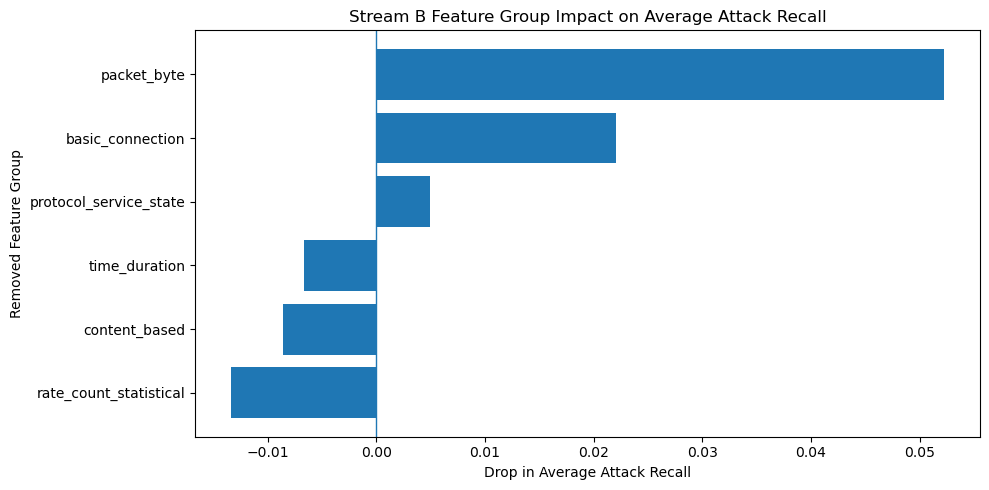

Saved: reports/stream_b_group_impact.png


In [13]:
plot_df = summary_df[summary_df["scenario"] != "All features"].copy()
plot_df = plot_df.sort_values("delta_avg_attack_recall", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    plot_df["dropped_group"],
    plot_df["delta_avg_attack_recall"]
)

ax.axvline(0, linewidth=1)

ax.set_xlabel("Drop in Average Attack Recall")
ax.set_ylabel("Removed Feature Group")
ax.set_title("Stream B Feature Group Impact on Average Attack Recall")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "stream_b_group_impact.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved: reports/stream_b_group_impact.png")

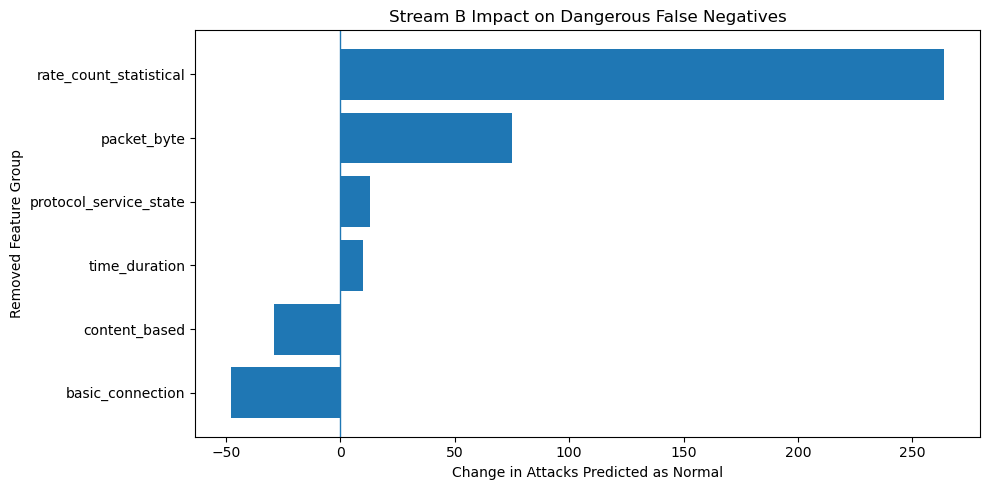

Saved: reports/stream_b_attack_to_normal_delta.png


In [14]:
fn_plot_df = summary_df[summary_df["scenario"] != "All features"].copy()
fn_plot_df = fn_plot_df.sort_values("delta_attack_to_normal", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    fn_plot_df["dropped_group"],
    fn_plot_df["delta_attack_to_normal"]
)

ax.axvline(0, linewidth=1)

ax.set_xlabel("Change in Attacks Predicted as Normal")
ax.set_ylabel("Removed Feature Group")
ax.set_title("Stream B Impact on Dangerous False Negatives")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "stream_b_attack_to_normal_delta.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved: reports/stream_b_attack_to_normal_delta.png")

In [15]:
baseline_recalls = (
    per_class_df[per_class_df["scenario"] == "All features"]
    .set_index("class")["recall"]
)

delta_rows = []

for scenario_name in stream_b_results:
    if scenario_name == "All features":
        continue

    scenario_recalls = (
        per_class_df[per_class_df["scenario"] == scenario_name]
        .set_index("class")["recall"]
    )

    for cls in classes:
        delta_rows.append({
            "scenario": scenario_name,
            "dropped_group": stream_b_results[scenario_name]["dropped_group"],
            "class": cls,
            "recall_delta": baseline_recalls.loc[cls] - scenario_recalls.loc[cls]
        })

recall_delta_df = pd.DataFrame(delta_rows)

recall_delta_pivot = recall_delta_df.pivot(
    index="dropped_group",
    columns="class",
    values="recall_delta"
)

recall_delta_pivot.to_csv(
    OUTPUT_DIR / "stream_b_recall_delta_by_class.csv"
)

recall_delta_pivot

class,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
dropped_group,,,,,,,,,,
basic_connection,0.007477,0.012876,-0.000611,0.021786,-0.010724,0.001624,0.001143,-0.006791,0.115894,0.057143
content_based,-0.007477,-0.002146,-0.006726,0.003706,-0.005774,-0.000255,0.000385,-0.005004,0.003311,-0.057143
packet_byte,0.011215,0.025751,0.029655,0.007412,0.012374,0.004710,0.000214,0.033238,0.003311,0.342857
protocol_service_state,-0.026168,-0.006438,0.081626,-0.001348,0.002681,-0.000534,-0.000025,-0.008935,0.003311,0.000000
rate_count_statistical,-0.134579,-0.053648,0.038215,0.022010,0.043102,-0.001253,0.000165,0.000715,-0.006623,-0.028571
time_duration,0.018692,0.000000,-0.014980,-0.001348,-0.000619,-0.001067,-0.000047,-0.003217,0.000000,-0.057143


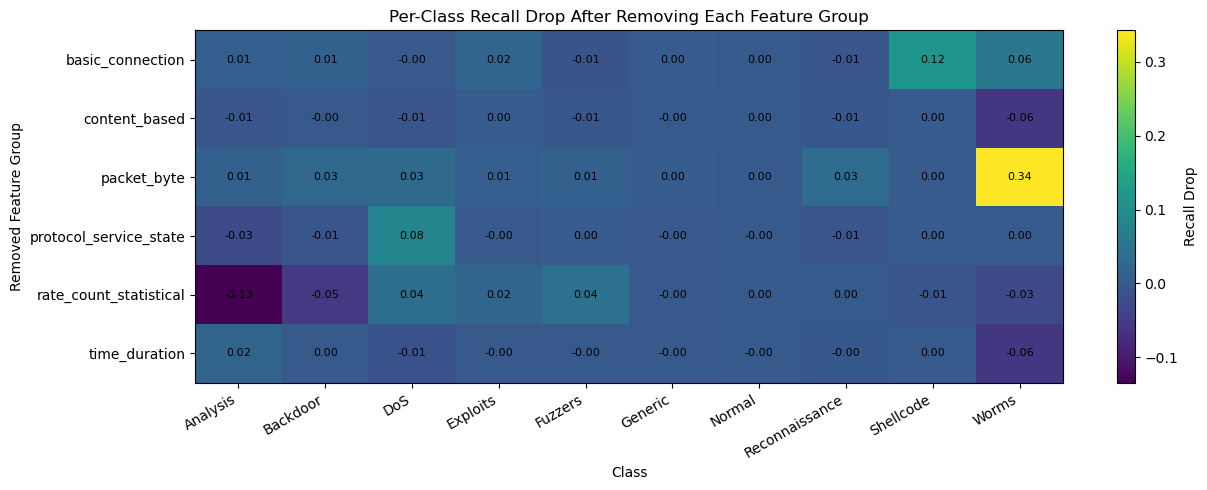

Saved: reports/stream_b_recall_delta_heatmap.png


In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

im = ax.imshow(
    recall_delta_pivot.values,
    aspect="auto"
)

ax.set_xticks(np.arange(len(recall_delta_pivot.columns)))
ax.set_yticks(np.arange(len(recall_delta_pivot.index)))

ax.set_xticklabels(recall_delta_pivot.columns, rotation=30, ha="right")
ax.set_yticklabels(recall_delta_pivot.index)

ax.set_title("Per-Class Recall Drop After Removing Each Feature Group")
ax.set_xlabel("Class")
ax.set_ylabel("Removed Feature Group")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Recall Drop")

for i in range(recall_delta_pivot.shape[0]):
    for j in range(recall_delta_pivot.shape[1]):
        value = recall_delta_pivot.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "stream_b_recall_delta_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved: reports/stream_b_recall_delta_heatmap.png")

In [17]:
ablation_only_df = summary_df[summary_df["scenario"] != "All features"].copy()

most_important_by_recall = ablation_only_df.sort_values(
    "delta_avg_attack_recall",
    ascending=False
).iloc[0]

most_dangerous_by_fn = ablation_only_df.sort_values(
    "delta_attack_to_normal",
    ascending=False
).iloc[0]

print("Most important group by average attack recall drop:")
print(most_important_by_recall[[
    "dropped_group",
    "avg_attack_recall",
    "delta_avg_attack_recall",
    "macro_f1",
    "delta_macro_f1",
    "attack_to_normal",
    "delta_attack_to_normal"
]])

print("\nMost important group by increase in attacks predicted as Normal:")
print(most_dangerous_by_fn[[
    "dropped_group",
    "avg_attack_recall",
    "delta_avg_attack_recall",
    "macro_f1",
    "delta_macro_f1",
    "attack_to_normal",
    "delta_attack_to_normal"
]])

Most important group by average attack recall drop:
dropped_group              packet_byte
avg_attack_recall             0.550446
delta_avg_attack_recall        0.05228
macro_f1                      0.565502
delta_macro_f1                0.042378
attack_to_normal                  1276
delta_attack_to_normal              75
Name: 3, dtype: object

Most important group by increase in attacks predicted as Normal:
dropped_group              rate_count_statistical
avg_attack_recall                         0.61613
delta_avg_attack_recall                 -0.013404
macro_f1                                 0.611263
delta_macro_f1                          -0.003383
attack_to_normal                             1465
delta_attack_to_normal                        264
Name: 5, dtype: object


In [18]:
stream_b_config = {
    "notebook": "05_stream_b_feature_group_ablation.ipynb",
    "purpose": "Interpretation using feature group ablation",
    "fixed_imbalance_strategy": BEST_IMBALANCE_STRATEGY,
    "fixed_encoding_strategy": BEST_ENCODING,
    "model": "RandomForestClassifier",
    "primary_metric": "average_attack_recall_excluding_Normal",
    "secondary_metrics": [
        "macro_f1",
        "per_class_recall",
        "attack_to_normal"
    ],
    "feature_groups": FEATURE_GROUPS,
    "outputs": [
        "data/outputs/stream_b_feature_group_summary.csv",
        "data/outputs/stream_b_per_class_recall.csv",
        "data/outputs/stream_b_recall_delta_by_class.csv",
        "reports/stream_b_group_impact.png",
        "reports/stream_b_attack_to_normal_delta.png",
        "reports/stream_b_recall_delta_heatmap.png"
    ]
}

with open(OUTPUT_DIR / "stream_b_config.json", "w") as f:
    json.dump(stream_b_config, f, indent=2)

print("Saved: data/outputs/stream_b_config.json")

Saved: data/outputs/stream_b_config.json


## Stream B Conclusion: Feature Group Ablation

Stream B was conducted to interpret the role of different feature groups in the UNSW-NB15 multiclass intrusion detection task. Unlike Stream A, which focuses on optimization, Stream B fixes the best preprocessing choices from Ablation 1 and Ablation 2 and removes one feature group at a time to observe how model behavior changes. This follows the project plan where Stream B is used for feature-group interpretation rather than feature-selection optimization.

The fixed Stream B pipeline was:

- Class imbalance strategy: `Capped_SMOTENC_50k`
- Encoding strategy: `Ordinal Encoding`
- Model: `RandomForestClassifier`
- Primary metric: average attack-class recall, excluding `Normal`
- Secondary metrics: macro F1, per-class recall, and attacks predicted as `Normal`

### Main finding: packet/byte features were most important for average attack recall

The most influential feature group for average attack-class recall was the `packet_byte` group.
When packet/byte features were removed, average attack recall decreased from `0.6027` to `0.5504`, giving the largest recall drop of `0.0523`. Macro F1 also decreased from `0.6079` to `0.5655`.
This suggests that packet and byte volume features provide important information for distinguishing attack categories. In particular, the per-class recall drop heatmap shows that removing packet/byte features strongly reduced recall for `Worms`, with a recall drop of about `0.34`. It also reduced recall for `DoS`, `Backdoor`, and `Reconnaissance`.
Therefore, packet/byte traffic volume appears to be one of the most important feature types for multiclass attack detection in this experiment.

### Secondary finding: basic connection features also contributed to attack detection

The `basic_connection` group had the second-largest average attack recall drop.
When basic connection features were removed, average attack recall decreased from `0.6027` to `0.5807`, giving a recall drop of `0.0221`. This group especially affected `Shellcode`, where recall dropped by about `0.12`, and `Worms`, where recall dropped by about `0.06`.
This suggests that connection-level features such as ports, TTL values, TCP window values, and TCP sequence-related fields help the model identify certain rare attack categories.

### Mixed finding: rate/count/statistical features increased dangerous false negatives

The `rate_count_statistical` group showed a mixed result.
Removing this group slightly increased average attack recall from `0.6027` to `0.6161`. However, it also caused attacks predicted as `Normal` to increase from `1,201` to `1,465`, an increase of `264` dangerous false negatives.
This means that although average attack recall improved, the model became worse in one security-critical aspect: more actual attacks were misclassified as normal traffic.
Therefore, the `rate_count_statistical` group should not be interpreted as simply unimportant. Instead, it appears to help prevent attacks from being classified as normal, even if it does not improve average attack recall under this metric.

### Less influential or possibly redundant groups

Removing `protocol_service_state` caused only a small average attack recall drop of about `0.0049`. This suggests that protocol, service, and state features were useful, but not as influential as packet/byte or basic connection features under the current Random Forest pipeline.
Removing `time_duration` and `content_based` features slightly improved average attack recall. This does not necessarily mean these features are useless. A safer interpretation is that these groups may be redundant with other traffic features or may introduce noise for the current model and preprocessing setup.

### Final interpretation

Overall, Stream B shows that `packet_byte` features had the strongest effect on average attack-class recall, while `rate_count_statistical` features had the strongest effect on dangerous false negatives.
The most important conclusion is:

- For improving average attack recall, `packet_byte` features were the most important.
- For preventing attacks from being predicted as `Normal`, `rate_count_statistical` features were important.
- `basic_connection` features were also useful, especially for rare classes such as `Shellcode` and `Worms`.

Therefore, Stream B suggests that traffic volume features and aggregated traffic pattern features play different but important roles in intrusion detection. Packet/byte features help distinguish attack categories, while rate/count/statistical features may help reduce security-critical false negatives.